# Practica1Preprocess

In [126]:
import pandas as pd
import numpy as np

import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

import sys
!{sys.executable} -m pip install feature_engine
!{sys.executable} -m pip install skrub

from feature_engine.imputation import MeanMedianImputer
from skrub import SquashingScaler

from sklearn.preprocessing import OrdinalEncoder

from feature_engine.encoding import CountFrequencyEncoder

from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import RobustScaler

In [127]:
#CARGAMOS EL DATASET

df1 = pd.read_csv("/content/df_train_small.csv")
df1.shape

(80000, 151)

## 1. SELECCION DE VARIABLES

In [128]:
#FILTRAMOS SOLO LAS VARIABLES QUE VAMOS A USAR PARA EL MODELADO

raw_predictors_vars = pd.read_excel("/content/variables_withExperts.xlsx")
raw_predictors_vars = ( raw_predictors_vars
                       .query("posible_predictora == 'si'")
                        .variable
                        .tolist())

df_train = df1[ raw_predictors_vars ]
df_train.shape

(80000, 101)

## 2. NULLS

In [129]:
(df_train.isnull().sum()/len(df_train)).sort_values(ascending=False).to_dict()

{'sec_app_mths_since_last_major_derog': 0.99705,
 'sec_app_revol_util': 0.99165,
 'sec_app_collections_12_mths_ex_med': 0.9915,
 'sec_app_open_acc': 0.9915,
 'sec_app_inq_last_6mths': 0.9915,
 'sec_app_open_act_il': 0.9915,
 'sec_app_chargeoff_within_12_mths': 0.9915,
 'sec_app_num_rev_accts': 0.9915,
 'sec_app_earliest_cr_line': 0.9915,
 'sec_app_mort_acc': 0.9915,
 'revol_bal_joint': 0.9915,
 'sec_app_fico_range_low': 0.9915,
 'sec_app_fico_range_high': 0.9915,
 'dti_joint': 0.9859625,
 'annual_inc_joint': 0.98595,
 'verification_status_joint': 0.98595,
 'mths_since_last_record': 0.82845,
 'mths_since_recent_bc_dlq': 0.760775,
 'mths_since_last_major_derog': 0.7346375,
 'il_util': 0.676475,
 'mths_since_recent_revol_delinq': 0.66205,
 'mths_since_rcnt_il': 0.63675,
 'open_acc_6m': 0.6272625,
 'total_bal_il': 0.6272625,
 'open_il_12m': 0.6272625,
 'total_cu_tl': 0.6272625,
 'open_rv_12m': 0.6272625,
 'open_rv_24m': 0.6272625,
 'open_il_24m': 0.6272625,
 'open_act_il': 0.6272625,
 'inq

In [130]:
#porcentaje de nulos de cada variable
nulls_vars = (df_train.isnull().sum()/len(df_train)).sort_values(ascending=False).to_frame(name="nulls_perc").reset_index()

#eliminamos todo lo que sea >50%
var_with_most_nulls = nulls_vars.query("nulls_perc >= 0.5")["index"].tolist()
df_train = df_train.drop(columns=var_with_most_nulls)
df_train.shape

(80000, 66)

In [131]:
# nulls <10% : imputamos por la moda en categoricas y numericas

nulls_10_perc = nulls_vars.query("nulls_perc < 0.10")["index"].tolist()
for var in nulls_10_perc:
  df_train[var] = df_train[var].fillna(df_train[var].mode()[0])

In [132]:
# nulls 10-50%: MeanMedianImputer

nulls_more_10_perc = nulls_vars.query("nulls_perc >= 0.10 and nulls_perc < 0.5")["index"].tolist()
median_imputer = MeanMedianImputer(imputation_method='median', variables=nulls_more_10_perc)
df_train = median_imputer.fit_transform(df_train)

In [133]:
#comprobamos que no quedan nulls:
(df_train.isnull().sum()/len(df_train)).sort_values(ascending=False).to_dict()

{'loan_amnt': 0.0,
 'term': 0.0,
 'int_rate': 0.0,
 'installment': 0.0,
 'grade': 0.0,
 'sub_grade': 0.0,
 'emp_title': 0.0,
 'emp_length': 0.0,
 'home_ownership': 0.0,
 'annual_inc': 0.0,
 'verification_status': 0.0,
 'purpose': 0.0,
 'zip_code': 0.0,
 'addr_state': 0.0,
 'dti': 0.0,
 'delinq_2yrs': 0.0,
 'earliest_cr_line': 0.0,
 'fico_range_low': 0.0,
 'fico_range_high': 0.0,
 'inq_last_6mths': 0.0,
 'open_acc': 0.0,
 'pub_rec': 0.0,
 'revol_bal': 0.0,
 'revol_util': 0.0,
 'total_acc': 0.0,
 'collections_12_mths_ex_med': 0.0,
 'application_type': 0.0,
 'acc_now_delinq': 0.0,
 'tot_coll_amt': 0.0,
 'tot_cur_bal': 0.0,
 'total_rev_hi_lim': 0.0,
 'acc_open_past_24mths': 0.0,
 'avg_cur_bal': 0.0,
 'bc_open_to_buy': 0.0,
 'bc_util': 0.0,
 'chargeoff_within_12_mths': 0.0,
 'delinq_amnt': 0.0,
 'mo_sin_old_il_acct': 0.0,
 'mo_sin_old_rev_tl_op': 0.0,
 'mo_sin_rcnt_rev_tl_op': 0.0,
 'mo_sin_rcnt_tl': 0.0,
 'mort_acc': 0.0,
 'mths_since_recent_bc': 0.0,
 'mths_since_recent_inq': 0.0,
 'num_a

## 3. VARIABLES CATEGORICAS

In [134]:
#miramos la cardinalidad de las variables categoricas

categoric_vars = ( df_train
                  .select_dtypes(include="object")
                  .columns
                  .tolist() )

categoric_vars_cardinality = ( df_train[categoric_vars]
                              .nunique()
                              .sort_values(ascending=False)
                              .to_frame(name="cardinality")
                              .reset_index())
categoric_vars_cardinality

,index,cardinality
0,emp_title,36885
1,zip_code,872
2,earliest_cr_line,634
3,addr_state,50
4,sub_grade,35
5,purpose,14
6,emp_length,11
7,grade,7
8,home_ownership,6
9,verification_status,3


In [135]:
df_train[categoric_vars]

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,purpose,zip_code,addr_state,earliest_cr_line,application_type
0,36 months,A,A3,Supervisory Personal Property,10+ years,MORTGAGE,Not Verified,home_improvement,225xx,VA,Nov-1990,Individual
1,36 months,B,B5,Terminal Manager,7 years,MORTGAGE,Source Verified,debt_consolidation,725xx,AR,Jun-1975,Individual
2,36 months,B,B3,Journeyman Meatcutter,6 years,RENT,Not Verified,credit_card,282xx,NC,Sep-2004,Individual
3,36 months,A,A5,owner,10+ years,OWN,Source Verified,debt_consolidation,351xx,AL,Oct-2000,Individual
4,36 months,B,B5,Owner,10+ years,MORTGAGE,Verified,debt_consolidation,465xx,IN,Nov-1989,Individual
...,...,...,...,...,...,...,...,...,...,...,...,...
79995,60 months,E,E1,Change Control,1 year,RENT,Source Verified,credit_card,300xx,GA,Oct-1998,Individual
79996,36 months,A,A2,Property Manager,< 1 year,RENT,Not Verified,debt_consolidation,066xx,CT,Nov-1995,Individual
79997,60 months,G,G4,Project Manager,6 years,RENT,Verified,debt_consolidation,926xx,CA,Aug-2004,Individual
79998,36 months,B,B5,Senior Accountant,8 years,RENT,Source Verified,debt_consolidation,223xx,VA,Jan-1998,Individual


In [136]:
#eliminamos zip_code: redundante con addr_state
df_train = df_train.drop(columns="zip_code")

In [137]:
#earliest_cr_line: lo separamos en mes y año
df_train['earliest_cr_line_dt'] = pd.to_datetime(df_train['earliest_cr_line'], format='%b-%Y')
df_train['earliest_cr_line_year'] = df_train['earliest_cr_line_dt'].dt.year
df_train['earliest_cr_line_month'] = df_train['earliest_cr_line_dt'].dt.month

df_train = df_train.drop(columns=['earliest_cr_line', 'earliest_cr_line_dt'])

In [138]:
#term: dejamos solo el numero
df_train["term"].value_counts()

,count
term,
36 months,60926
60 months,19074


In [139]:
df_train["term"] = df_train["term"].str.replace(" months", "").astype(int)

In [140]:
#emp_length
df_train["emp_length"].value_counts()

,count
emp_length,
10+ years,30701
2 years,7226
3 years,6413
< 1 year,6371
1 year,5368
5 years,5043
4 years,4883
6 years,3766
8 years,3702


In [141]:
# 1. Mapeamos los casos especiales primero
mapping = {'10+ years': 11, '< 1 year': 0}

# 2. Aplicamos el reemplazo y para el resto extraemos solo los dígitos
df_train['emp_length'] = df_train['emp_length'].replace(mapping)

# 3. Limpiamos los que todavía tienen texto (como "2 years", "3 years"...)
# Usamos .str.extract para quedarnos solo con el número y convertimos a float
df_train['emp_length'] = df_train['emp_length'].astype(str).str.extract('(\d+)').astype(int)

# Verificamos el resultado
print(df_train['emp_length'].value_counts().sort_index())

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5867/4052315324.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_train['emp_length'] = df_train['emp_length'].astype(str).str.extract('(\d+)').astype(int)


emp_length
0      6371
1      5368
2      7226
3      6413
4      4883
5      5043
6      3766
7      3556
8      3702
9      2971
11    30701
Name: count, dtype: int64


In [142]:
# grade y sub_grade: OrdinalEncoder

encoder = OrdinalEncoder()
df_train[['grade', 'sub_grade']] = encoder.fit_transform(df_train[['grade', 'sub_grade']]).astype(int)

In [143]:
#one hot encoder: variables cardinalidad baja

ohe_categorical_1 = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
columnas_a_codificar_1 = ['home_ownership', 'verification_status', 'application_type', 'purpose']
df_train = df_train.reset_index(drop=True)
ohe_vars_cat1 = ohe_categorical_1.fit_transform(df_train[columnas_a_codificar_1])
ohe_df_cat1 = pd.DataFrame(ohe_vars_cat1, columns=ohe_categorical_1.get_feature_names_out())
df_train = pd.concat([df_train, ohe_df_cat1], axis=1)
df_train = df_train.drop(columns=columnas_a_codificar_1)
print(df_train.shape)

(80000, 87)


In [144]:
# emp_title y addr_state: CountFrequencyEncoder (cardinalidad media y alta)

freq_encoder = CountFrequencyEncoder(encoding_method='frequency', variables=['emp_title', 'addr_state']) #se "sustituye" por la frecuencia con la que aparece
df_train = freq_encoder.fit_transform(df_train)

In [145]:
df_train[['emp_title', 'addr_state']].head()

,emp_title,addr_state
0,0.000013,0.028925
1,0.000050,0.007663
2,0.000013,0.027262
3,0.003025,0.012688
4,0.007687,0.015675


In [146]:
#comprobamos que hemos tratado todas las variables categoricas
df_train.select_dtypes(include="object").columns.tolist()

[]

In [147]:
df_train.shape

(80000, 87)

## 4. NUEVAS FEATURES

In [148]:
# combinar fico_range_low y fico_range_high en un fico_medio
df_train['prob_low'] = (df_train["fico_range_low"] - 300) / (850 - 300)
df_train['prob_high'] = (df_train["fico_range_high"] - 300) / (850 - 300)
df_train['prob_medio'] = (df_train["prob_low"] + df_train["prob_high"]) / 2
df_train["prediction"] = np.where(df_train["prob_medio"] > 0.67, 0, 1)

df_train['fico_medio'] = ((df_train['fico_range_low'] + df_train['fico_range_high']) / 2).astype(int)
df_train.shape

(80000, 92)

In [149]:
# deuda_total / ingreso_anual
df_train['deuda_total'] = (df_train['dti'] * df_train['annual_inc']).astype(int)
df_train.shape

(80000, 93)

In [150]:
# discretizar variables continuas en rangos

labels_4_tramos = ["Bajo", "Medio-Bajo", "Medio-Alto", "Alto"]
df_train['ingresos_bins'] = pd.qcut(df_train['annual_inc'], q=4, labels=labels_4_tramos)
df_train['patrimonio_bins'] = pd.qcut(df_train['tot_cur_bal'], q=4, labels=labels_4_tramos)

# 2. Discretización de Ratio Deuda-Ingresos (DTI) con límites específicos
# Definimos los cortes exactos que pediste
bins_dti = [-np.inf, 20, 35, 50, np.inf]
labels_dti = ["Saludable", "Aceptable", "Alerta", "Riesgo Alto"]
df_train['dti_bins'] = pd.cut(df_train['dti'], bins=bins_dti, labels=labels_dti)

# Verificación rápida
print(df_train.shape)


(80000, 96)


In [151]:
print(df_train[['ingresos_bins', 'patrimonio_bins', 'dti_bins', "fico_medio", "deuda_total"]].head())

  ingresos_bins patrimonio_bins   dti_bins  fico_medio  deuda_total
0          Alto            Alto  Aceptable         722      3408600
1          Alto      Medio-Bajo  Saludable         662      1142091
2          Bajo      Medio-Bajo  Aceptable         672       666240
3          Bajo            Bajo  Aceptable         742       811199
4    Medio-Alto            Alto  Saludable         677      1316250


In [152]:
# ONE HOT ENCODING
ohe_bins = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
columnas_a_codificar_2 = ['ingresos_bins', 'patrimonio_bins', 'dti_bins']
df_train = df_train.reset_index(drop=True)
ohe_vars_bins = ohe_bins.fit_transform(df_train[columnas_a_codificar_2])
ohe_df_bins = pd.DataFrame(ohe_vars_bins, columns=ohe_bins.get_feature_names_out())
df_train = pd.concat([df_train, ohe_df_bins], axis=1)
df_train = df_train.drop(columns=columnas_a_codificar_2)
print(df_train.shape)

(80000, 105)


## 5. VARIABLE NUMERICAS

In [153]:
# 1. Eliminar duplicados: filas
df_train = df_train.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones finales: Train: {df_train.shape}")

Dimensiones finales: Train: (80000, 105)


In [154]:
# RobustScaler: evita que los outliers distorsionen la escala de los datos

numeric_cols = df_train.select_dtypes(include='number').columns
robust_scaler = RobustScaler()
df_train[numeric_cols] = robust_scaler.fit_transform(df_train[numeric_cols])

In [155]:
df_train.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,addr_state,...,ingresos_bins_Medio-Alto,ingresos_bins_Medio-Bajo,patrimonio_bins_Alto,patrimonio_bins_Bajo,patrimonio_bins_Medio-Alto,patrimonio_bins_Medio-Bajo,dti_bins_Aceptable,dti_bins_Alerta,dti_bins_Riesgo Alto,dti_bins_Saludable
0,-0.327869,0.0,-0.825321,-0.376384,-2.0,-1.000,-0.050847,0.500,1.475914,-0.067220,...,0.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0
1,0.491803,0.0,-0.193910,0.660190,-1.0,-0.125,0.000000,0.000,0.938681,-0.420124,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
2,-0.475410,0.0,-0.280449,-0.515429,-1.0,-0.375,-0.050847,-0.125,-0.749310,-0.094813,...,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,-1.0
3,-0.147541,0.0,-0.777244,-0.166055,-2.0,-0.750,4.033898,0.500,-0.930961,-0.336722,...,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,-1.0
4,0.245902,0.0,-0.200321,0.361646,-1.0,-0.125,10.355932,0.500,0.227064,-0.287137,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [156]:
df_train.shape

(80000, 105)

## 6. PREPARACION MATRIZ FINAL

In [157]:
y_train = df1["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})
X_train = df_train

print("X: ", X_train.shape)
print("y: ",y_train.shape)

X:  (80000, 105)
y:  (80000,)


In [158]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [159]:
rf_model.score(X_train, y_train)

1.0

## 7. REPETIMOS EN TEST

In [160]:
#CARGAMOS EL DATASET

df2 = pd.read_csv("/content/df_test_small.csv")
df2.shape

(20000, 151)

In [161]:
#FILTRAMOS SOLO LAS VARIABLES QUE VAMOS A USAR PARA EL MODELADO

df_test = df2[raw_predictors_vars]
df_test.shape

(20000, 101)

In [162]:
#  NULLS
df_test = df_test.drop(columns=var_with_most_nulls)
df_test.shape

(20000, 66)

In [163]:
# nulls <10% : imputamos por la moda en categoricas y numericas
for var in nulls_10_perc:
  df_test[var] = df_test[var].fillna(df_test[var].mode()[0])

In [164]:
# nulls 10-50%: MeanMedianImputer
median_imputer = MeanMedianImputer(imputation_method='median', variables=nulls_more_10_perc)
df_test = median_imputer.fit_transform(df_test)

In [165]:
#comprobamos que no quedan nulls:
(df_test.isnull().sum()/20000).sort_values(ascending=False).to_dict()

{'loan_amnt': 0.0,
 'term': 0.0,
 'int_rate': 0.0,
 'installment': 0.0,
 'grade': 0.0,
 'sub_grade': 0.0,
 'emp_title': 0.0,
 'emp_length': 0.0,
 'home_ownership': 0.0,
 'annual_inc': 0.0,
 'verification_status': 0.0,
 'purpose': 0.0,
 'zip_code': 0.0,
 'addr_state': 0.0,
 'dti': 0.0,
 'delinq_2yrs': 0.0,
 'earliest_cr_line': 0.0,
 'fico_range_low': 0.0,
 'fico_range_high': 0.0,
 'inq_last_6mths': 0.0,
 'open_acc': 0.0,
 'pub_rec': 0.0,
 'revol_bal': 0.0,
 'revol_util': 0.0,
 'total_acc': 0.0,
 'collections_12_mths_ex_med': 0.0,
 'application_type': 0.0,
 'acc_now_delinq': 0.0,
 'tot_coll_amt': 0.0,
 'tot_cur_bal': 0.0,
 'total_rev_hi_lim': 0.0,
 'acc_open_past_24mths': 0.0,
 'avg_cur_bal': 0.0,
 'bc_open_to_buy': 0.0,
 'bc_util': 0.0,
 'chargeoff_within_12_mths': 0.0,
 'delinq_amnt': 0.0,
 'mo_sin_old_il_acct': 0.0,
 'mo_sin_old_rev_tl_op': 0.0,
 'mo_sin_rcnt_rev_tl_op': 0.0,
 'mo_sin_rcnt_tl': 0.0,
 'mort_acc': 0.0,
 'mths_since_recent_bc': 0.0,
 'mths_since_recent_inq': 0.0,
 'num_a

In [166]:
#  CATEGORICAS

# 1.
df_test = df_test.drop(columns="zip_code")

In [167]:
#2.
df_test['earliest_cr_line_dt'] = pd.to_datetime(df_test['earliest_cr_line'], format='%b-%Y')
df_test['earliest_cr_line_year'] = df_test['earliest_cr_line_dt'].dt.year
df_test['earliest_cr_line_month'] = df_test['earliest_cr_line_dt'].dt.month

df_test = df_test.drop(columns=['earliest_cr_line', 'earliest_cr_line_dt'])

In [168]:
# 3.
df_test["term"] = df_test["term"].str.replace(" months", "").astype(int)

In [169]:
# 4.
mapping = {'10+ years': 11, '< 1 year': 0}
df_test['emp_length'] = df_test['emp_length'].replace(mapping)
df_test['emp_length'] = df_test['emp_length'].astype(str).str.extract('(\d+)').astype(int)
print(df_test['emp_length'].value_counts().sort_index())

emp_length
0     1652
1     1307
2     1820
3     1622
4     1219
5     1274
6      921
7      902
8      900
9      767
11    7616
Name: count, dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5867/1216584242.py:4: SyntaxWarning: invalid escape sequence '\d'
  df_test['emp_length'] = df_test['emp_length'].astype(str).str.extract('(\d+)').astype(int)


In [170]:
# 5.
encoder = OrdinalEncoder()
df_test[['grade', 'sub_grade']] = encoder.fit_transform(df_test[['grade', 'sub_grade']]).astype(int)

In [171]:
# 6.
ohe_vars_cat1_test = ohe_categorical_1.transform(df_test[columnas_a_codificar_1])
ohe_df_cat1_test = pd.DataFrame(ohe_vars_cat1_test, columns=ohe_categorical_1.get_feature_names_out())
df_test = pd.concat([df_test, ohe_df_cat1_test], axis=1)
df_test = df_test.drop(columns=columnas_a_codificar_1)
print(df_test.shape)

(20000, 87)


In [172]:
# 7.
freq_encoder = CountFrequencyEncoder(encoding_method='frequency', variables=['emp_title', 'addr_state']) #se "sustituye" por la frecuencia con la que aparece
df_test = freq_encoder.fit_transform(df_test)

In [173]:
df_test.shape

(20000, 87)

In [174]:
#comprobamos que hemos tratado todas las variables categoricas
df_test.select_dtypes(include="object").columns.tolist()

[]

In [175]:
#4.NUEVAS FEATURES
df_test['prob_low'] = (df_test["fico_range_low"] - 300) / (850 - 300)
df_test['prob_high'] = (df_test["fico_range_high"] - 300) / (850 - 300)
df_test['prob_medio'] = (df_test["prob_low"] + df_test["prob_high"]) / 2
df_test["prediction"] = np.where(df_test["prob_medio"] > 0.67, 0, 1)

df_test['fico_medio'] = ((df_test['fico_range_low'] + df_test['fico_range_high']) / 2).astype(int)
df_test.shape

(20000, 92)

In [176]:
# deuda_total / ingreso_anual
df_test['deuda_total'] = (df_test['dti'] * df_test['annual_inc']).astype(int)
df_test.shape

(20000, 93)

In [177]:
# discretizar variables continuas en rangos

labels_4_tramos = ["Bajo", "Medio-Bajo", "Medio-Alto", "Alto"]
df_test['ingresos_bins'] = pd.qcut(df_test['annual_inc'], q=4, labels=labels_4_tramos)
df_test['patrimonio_bins'] = pd.qcut(df_test['tot_cur_bal'], q=4, labels=labels_4_tramos)

# 2. Discretización de Ratio Deuda-Ingresos (DTI) con límites específicos
# Definimos los cortes exactos que pediste
bins_dti = [-np.inf, 20, 35, 50, np.inf]
labels_dti = ["Saludable", "Aceptable", "Alerta", "Riesgo Alto"]
df_test['dti_bins'] = pd.cut(df_test['dti'], bins=bins_dti, labels=labels_dti)

# Verificación rápida
print(df_test.shape)


(20000, 96)


In [178]:
# ONE HOT ENCODING
df_test = df_test.reset_index(drop=True)
ohe_vars_bins_test = ohe_bins.transform(df_test[columnas_a_codificar_2])
ohe_df_bins_test = pd.DataFrame(ohe_vars_bins_test, columns=ohe_bins.get_feature_names_out())
df_test = pd.concat([df_test, ohe_df_bins_test], axis=1)
df_test = df_test.drop(columns=columnas_a_codificar_2)
print(df_test.shape)

(20000, 105)


In [179]:
#  NUMERICAS

# 1. Eliminar duplicados: filas
df_test = df_test.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones finales: Train: {df_test.shape}")

Dimensiones finales: Train: (20000, 105)


In [180]:
# 2.
numeric_cols = df_test.select_dtypes(include='number').columns
df_test[numeric_cols] = robust_scaler.transform(df_test[numeric_cols])

In [181]:
y_test = df2["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})
X_test = df_test.reindex(columns=X_train.columns, fill_value=0)

print("X: ", X_test.shape)
print("y: ",y_test.shape)

X:  (20000, 105)
y:  (20000,)


In [182]:
rf_model.score(X_test, y_test)

0.80245

In [183]:
# hacemos un predict.
class_predicted = rf_model.predict(X_test)
prob_predicted = rf_model.predict_proba(X_test)[:,1]
prob_predicted

array([0.17, 0.12, 0.05, ..., 0.17, 0.25, 0.37])

In [184]:
# metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, class_predicted))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89     16003
           1       0.55      0.06      0.11      3997

    accuracy                           0.80     20000
   macro avg       0.68      0.52      0.50     20000
weighted avg       0.76      0.80      0.73     20000



AUC: 0.6976408804760166


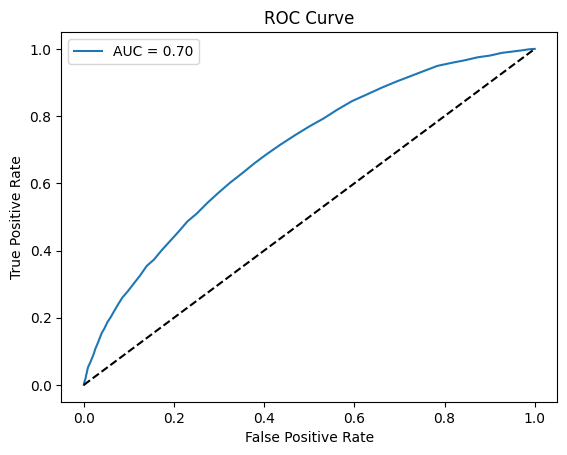

In [185]:
# ahora el area bajo la curva ROC y pintamos la curva ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, prob_predicted)
print(f"AUC: {auc}")
fpr, tpr, thresholds = roc_curve(y_test, prob_predicted)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Practica1Filtering

In [186]:
#1. Eliminacion de features correlacionadas
from feature_engine.selection import DropCorrelatedFeatures

correlated_dropper = DropCorrelatedFeatures(threshold=0.9, method="pearson", missing_values="ignore")

correlated_dropper.fit(X_train)
print("Variables eliminadas:", correlated_dropper.features_to_drop_)
X_train = correlated_dropper.transform(X_train)
print("Shape TRAIN: ", X_train.shape)
X_test = correlated_dropper.transform(X_test)
print("Shape TEST: ", X_test.shape)

Variables eliminadas: ['application_type_Joint App', 'dti_bins_Saludable', 'fico_range_high', 'fico_range_low', 'prob_high', 'prob_low', 'prob_medio', 'int_rate', 'sub_grade', 'loan_amnt', 'num_rev_tl_bal_gt_0', 'open_acc', 'tot_hi_cred_lim']
Shape TRAIN:  (80000, 92)
Shape TEST:  (20000, 92)


In [187]:
#2. Eliminamos variables filtradas por varianza
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.95)

selector.fit(X_train)

variables_antes = X_train.columns
variables_despues = selector.get_feature_names_out()
variables_eliminadas = [v for v in variables_antes if v not in variables_despues]

print("Variables eliminadas:", variables_eliminadas)
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)
print("Shape TRAIN: ", X_train.shape)
print("Shape TEST:  ", X_test.shape)

Variables eliminadas: ['installment', 'emp_length', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_cur_bal', 'acc_open_past_24mths', 'bc_util', 'chargeoff_within_12_mths', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_recent_inq', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'earliest_cr_line_year', 'earliest_cr_line_month', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'application_type_Individual', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 

In [188]:
#3. Seleccion de features - ProbeFeatureSelection

from feature_engine.selection import ProbeFeatureSelection
from sklearn.ensemble import RandomForestClassifier

sel = ProbeFeatureSelection(
    estimator=RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
    variables=None,
    scoring="roc_auc",
    n_probes=10,
    distribution="normal",
    cv=3,
    random_state=150,
    confirm_variables=False
)

sel.fit(X_train, y_train)
print("Variables eliminadas:", sel.features_to_drop_)
X_train = sel.transform(X_train)
print("Shape TRAIN: ", X_train.shape)
X_test = sel.transform(X_test)
print("Shape TESTs: ", X_test.shape)

Variables eliminadas: ['x5', 'x9', 'x14', 'x22', 'x23']
Shape TRAIN:  (80000, 20)
Shape TESTs:  (20000, 20)


In [ ]:
def clean_duplicates(X, y):
    duplicados = X.duplicated(keep='first')

    X_clean = X[~duplicados].reset_index(drop=True)
    y_clean = y[~duplicados].reset_index(drop=True)

    return X_clean, y_clean

# Aplicar a tus datasets
X_train, y_train = clean_duplicates(X_train, y_train)
X_test, y_test = clean_duplicates(X_test, y_test)

In [190]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf.score(X_test, y_test)

0.8002

In [191]:
# hacemos un predict.
class_predict = rf.predict(X_test)
prob_predict = rf.predict_proba(X_test)[:,1]
prob_predict

array([0.05, 0.13, 0.03, ..., 0.28, 0.23, 0.5 ])

In [192]:
# metrics
print(classification_report(y_test, class_predict))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89     16003
           1       0.50      0.06      0.11      3997

    accuracy                           0.80     20000
   macro avg       0.65      0.52      0.50     20000
weighted avg       0.75      0.80      0.73     20000



AUC: 0.6813518796849308


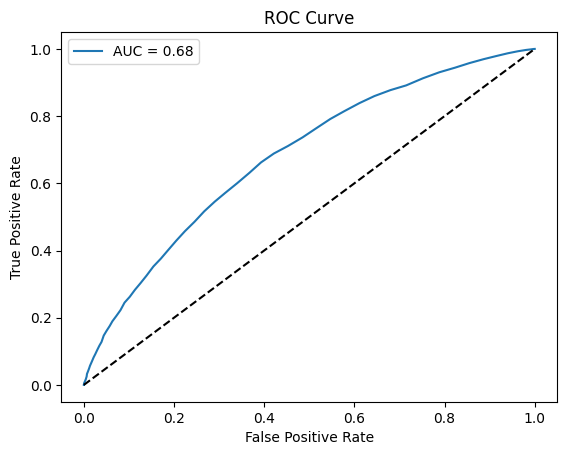

In [193]:
# ahora el area bajo la curva ROC y pintamos la curva ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, prob_predict)
print(f"AUC: {auc}")
fpr, tpr, thresholds = roc_curve(y_test, prob_predict)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()